<a href="https://colab.research.google.com/github/pramodshetyy780-del/AI_ML_programs_PRAMOD/blob/main/PROJECT_GWQA_pramod%2Ckavya%2Camruthavarshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving groundwater_300_samples.xlsx to groundwater_300_samples.xlsx
Dataset Loaded:
      pH    EC   TDS  Alkalinity  Hardness   Cl     F  NO3  SO4  Water_Quality
0  7.25  1676   900         154       210  130  1.63   23  102              0
1  8.40  1791  1123         306       363  122  1.25   45  108              0
2  7.96  1683   802         196       312  269  1.07   42  109              0
3  7.70   846   706         217       386  237  1.44   32  118              0
4  6.81  1666   728         225       494  259  1.13   11  187              0

Random Forest Results:
Accuracy: 0.95
Confusion Matrix:
 [[57  0]
 [ 3  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        57
           1       0.00      0.00      0.00         3

    accuracy                           0.95        60
   macro avg       0.47      0.50      0.49        60
weighted avg       0.90      0.95      0.93        60


Decision Tree Resu

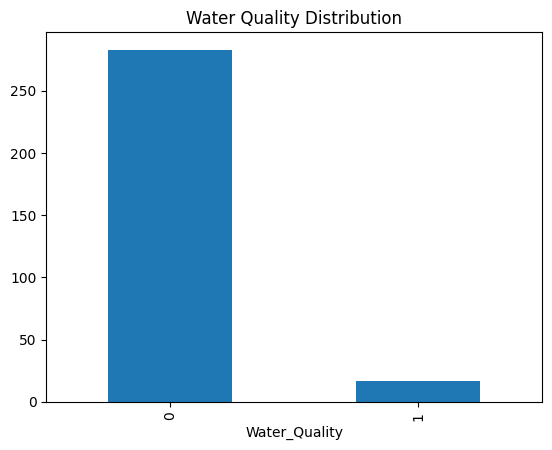

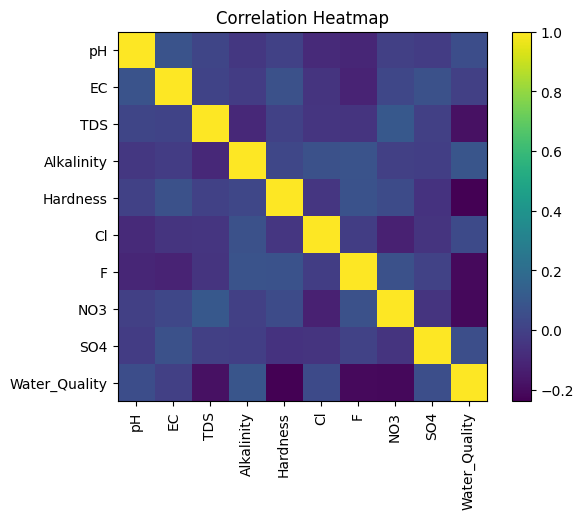

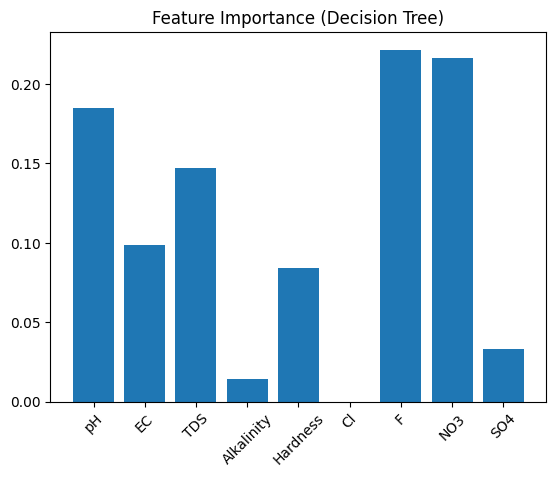


Enter Water Quality Parameters:
pH: 6
EC: 1.2
TDS: 200
Alkalinity: 12
Hardness: 3
Cl: 0.7
F: 0.7
NO3: 12
SO4: 0.45

Prediction: ❌ Unsafe Water


In [ ]:
# --- 1. Upload File in Colab ---
from google.colab import files
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]


# --- 2. Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


# --- 3. Load Dataset ---
if file_name.endswith('.csv'):
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

print("Dataset Loaded:\n", df.head())


# --- 4. Feature Selection ---
features = ['pH', 'EC', 'TDS', 'Alkalinity', 'Hardness', 'Cl', 'F', 'NO3', 'SO4']

X = df[features]
y = df['Water_Quality']


# --- 5. Preprocessing ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# --- 6. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# --- 7. Model Training ---
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


# --- 8. Best Model ---
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)


# --- 9. Visualization ---

# 1. Water Quality Distribution
plt.figure()
df['Water_Quality'].value_counts().plot(kind='bar')
plt.title("Water Quality Distribution")
plt.show()

# 2. Correlation Heatmap
plt.figure()
corr = df.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# 3. Feature Importance
best = models[best_model]
importances = best.feature_importances_

plt.figure()
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance (" + best_model + ")")
plt.show()


# --- 10. User Input for Prediction ---
print("\nEnter Water Quality Parameters:")

ph = float(input("pH: "))
ec = float(input("EC: "))
tds = float(input("TDS: "))
alk = float(input("Alkalinity: "))
hard = float(input("Hardness: "))
cl = float(input("Cl: "))
f = float(input("F: "))
no3 = float(input("NO3: "))
so4 = float(input("SO4: "))

sample = [[ph, ec, tds, alk, hard, cl, f, no3, so4]]
sample_scaled = scaler.transform(sample)

prediction = models[best_model].predict(sample_scaled)

print("\nPrediction:",
      "Safe Water" if prediction[0] == 1 else "Unsafe Water")